In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
sys.path.append(os.path.abspath('..'))
from src.wiserep import plot_spectra

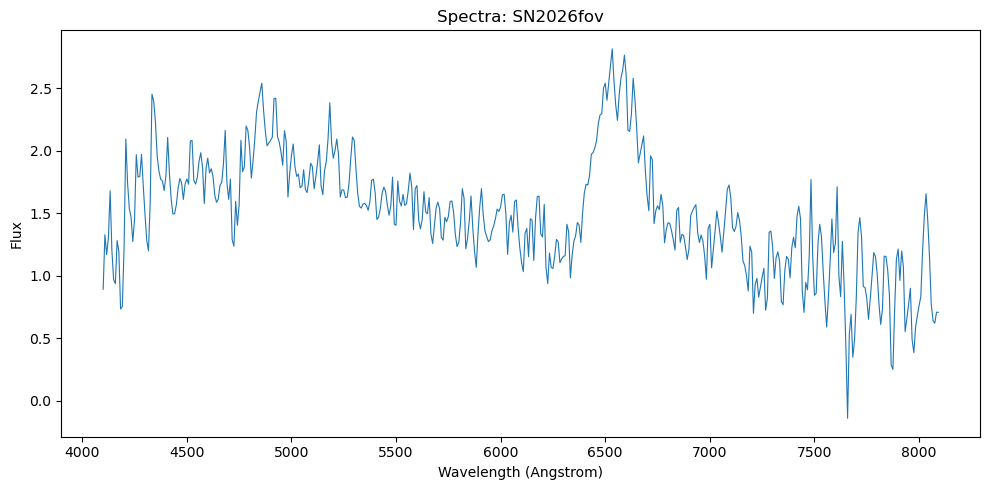

In [5]:
target_name='SN2026fov'
filedir=f'../output/{target_name}/spectrum/'
filepath=list(Path(filedir).glob('*.dat'))

plot_spectra(filepath, target_name, jupyter=True)


In [ ]:
import astrodash
import PyQt5

# 使用绝对路径
notebook_dir = Path(os.path.abspath('')).resolve()
project_root = notebook_dir.parent  # notebooks/ → project root
filename_str = str(project_root / 'output' / target_name / 'spectrum' / 'spectrum_90622.dat')

print(f'📂 光谱文件: {filename_str}')
print(f'✅ 文件存在: {Path(filename_str).exists()}')

print("正在启动 DASH 进行模板匹配和深度学习分类...")

# 初始化分类器，传入你的文件名
host_galaxy_z = None  # 如果没有，填 None

try:
    # 运行分类器
    classification = astrodash.Classify(
        filenames=[filename_str],  # 光谱文件路径
        knownZ=host_galaxy_z,      # 已知红移
        smooth=6                   # 平滑参数
    )
    
    # 获取最佳匹配 (返回格式因 astrodash/tf 版本而异)
    ret = classification.list_best_matches()
    if len(ret) >= 3:
        # TF ≥ 2.16: ret[2] 是 best_fits 列表
        best_fits = ret[2]
    else:
        # 旧格式: ret = (best_fits, rejected_fits)
        best_fits = ret[0]
    
    if best_fits:
        best_match = best_fits[0]
        sn_name = best_match[0]        
        sn_type = best_match[1]        
        sn_age = best_match[2]         
        # 4-元素格式 (带红移) 仅在部分版本中可用
        sn_z = best_match[3] if len(best_match) >= 4 else None
        
        print("-" * 40)
        print(f"🎯 DASH 最终分类结果 (基于已知红移 z={host_galaxy_z}):")
        print(f"超新星类型 (Type): {sn_type}")
        print(f"演化阶段 (Age): {sn_age} days (相对于光变极大期)")
        if sn_z is not None:
            print(f"拟合红移 (z): {sn_z:.4f}")
        print(f"最匹配的标准模板: {sn_name}")
        print("-" * 40)
    else:
        print("未找到合适的匹配模板。")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"❌ DASH 运行过程中发生错误: {e}")

📂 光谱文件: E:\THU\astronomy\Obsastro\hw\p2\obsastro-sn-pipeline\output\SN2026fov\spectrum\spectrum_90622.dat
✅ 文件存在: True
正在启动 DASH 进行模板匹配和深度学习分类...
INFO:tensorflow:Restoring parameters from d:\Anaconda\envs\astro_env\lib\site-packages\astrodash\models_v06\models/agnosticZ/tensorflow_model.ckpt


d:\Anaconda\envs\astro_env\lib\site-packages\astrodash\preprocessing.py:88: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(self.filename, header=None, delim_whitespace=True).values
d:\Anaconda\envs\astro_env\lib\site-packages\astrodash\read_binned_templates.py:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  hostInfos = np.array([[np.zeros(nw), np.zeros(nw), 1, nw - 1]])


0.0
0.0
0.0020525374138740116
0.0010257426329625119
0.007202331349592583
0.00823546172087708
0.006170259618283103
0.007202331349592583
0.4155930152590164
0.012378591340323375
0.421410094278029
0.25172488127699233
0.4155930152590164
0.014456536276054477
0.00823546172087708
0.009269651818028635
0.4184985728856543
0.007202331349592583
0.11251426730450187
0.015497107594600212
Finished classifying 1 spectra!
----------------------------------------
🎯 DASH 最终分类结果 (基于已知红移 z=0.00222):
超新星类型 (Type): 2 to 18
演化阶段 (Age): 0.9999 days (相对于光变极大期)
最匹配的标准模板: IIP
----------------------------------------


In [ ]:
# 假设前一步 DASH 告诉你这是一颗 Ia 型超新星 (有极强的 Si II 吸收线)
# 或者是一颗 II 型超新星 (有极强的 H-alpha 吸收线)

# 1. 选择我们要测量的特征谱线 (静止波长)
# 如果是 Ia 型，取消注释这行：
# rest_wave = 6355.0  # 硅离子 Si II 的特征波长
# 如果是 II 型，取消注释这行：
rest_wave = 6562.8  # 氢的巴耳末系 H-alpha 波长

c = 299792.458 # 光速 (km/s)

# 2. 去除红移 (De-redshift)
# 利用 Cell 2 中拟合出来的红移 sn_z，把观测波长还原到超新星的静止参考系
wave_rest_frame = wave / (1 + sn_z)

# 3. 利用 NumPy 切片寻找吸收谷 (Absorption Trough)
# 膨胀速度通常在 5000 ~ 20000 km/s，对应的波长蓝移大约在 100 ~ 400 埃
search_min = rest_wave - 500 # 搜索下限
search_max = rest_wave       # 搜索上限

# 使用布尔索引 (NumPy的精髓) 截取特征谱线附近的数据
mask = (wave_rest_frame > search_min) & (wave_rest_frame < search_max)
local_wave = wave_rest_frame[mask]
local_flux = flux_smoothed[mask]

# 找到这段区间内流量最小的点 (即吸收线中心)
min_idx = np.argmin(local_flux)
obs_abs_wave = local_wave[min_idx]

# 4. 计算膨胀速度 (非相对论多普勒公式 v = c * Δλ / λ)
v_exp = c * (rest_wave - obs_abs_wave) / rest_wave

print(f"谱线静止波长: {rest_wave} A")
print(f"实际观测到的吸收谷波长: {obs_abs_wave:.1f} A")
print(f"🚀 结论：抛射物膨胀速度 v_exp = {v_exp:.0f} km/s")

# 5. 画个局部放大图展示成果
plt.figure(figsize=(8, 4))
plt.plot(local_wave, local_flux, 'b-', label='Smoothed Spectrum')
plt.axvline(rest_wave, color='red', linestyle='--', label='Rest Wavelength (Zero Velocity)')
plt.axvline(obs_abs_wave, color='green', linestyle=':', label='Observed Minimum')
plt.title(f'P-Cygni Absorption Feature (v = {v_exp:.0f} km/s)')
plt.xlabel('Rest-frame Wavelength ($\AA$)')
plt.legend()
plt.show()